In [1]:
from utils import english_to_chinese
import os
os.environ['HF_HOME'] = "../"
from train import load_mm_data
import asyncio
import datasets
import copy
import glob
import re

/root/autodl-tmp/Qwen3-SmVL/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/root/autodl-tmp/Qwen3-SmVL/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data = load_mm_data(select_data="all", seed=42)

In [85]:
data["train"][0]

{'images': [<PIL.PngImagePlugin.PngImageFile image mode=RGBA size=448x448>],
 'texts': [{'user': 'How many objects are preferred by more than 4 people in at least one category?\nEnsure brevity in your answer. ',
   'assistant': 'Three.',
   'source': 'dvqa'},
  {'user': 'Which object is the least preferred in any category?\nOffer a very short reply.',
   'assistant': 'Patent.',
   'source': 'dvqa'},
  {'user': 'How many people like the least preferred object in the whole chart?\nProvide a succinct answer.',
   'assistant': '2.',
   'source': 'dvqa'},
  {'user': 'Which object is preferred by the least number of people summed across all the categories?\nYour response must be concise.',
   'assistant': 'Baby.',
   'source': 'dvqa'},
  {'user': 'Which object is preferred by the most number of people summed across all the categories?\nProvide a short and direct response.',
   'assistant': 'Driver.',
   'source': 'dvqa'},
  {'user': 'How many total people preferred the object baby across all

In [3]:
def combine_msg(example):
    combined_list = []
    combined_list.append("<样本>")
    for turn in example["texts"]:
        combined_list.append("<对话>")
        combined_list.append("<用户>" + turn["user"])
        combined_list.append("<助手>" + turn["assistant"])
    all_list.append("".join(combined_list))

In [12]:
all_list = []
start_index = 136
end_index = 144
selected_range = range(start_index, end_index)
data["train"].select(selected_range).map(combine_msg)

Map: 100%|██████████| 8/8 [00:00<00:00, 936.02 examples/s]


Dataset({
    features: ['images', 'texts'],
    num_rows: 8
})

In [13]:
all_list

["<样本><对话><用户>What's the sum of Net interest income of Year Ended December 31, 2016 Consolidated, Note payable to Comcast of 2015, and Total revenue of Year Ended December 31, 2016 Consolidated ?<助手>\nComputations: ((3758.0 + 1750.0) + 5255.0)\nAnswer: 10763.0.",
 '<样本><对话><用户>What parked next to the small building\nGive a very brief answer.<助手>Bus.<对话><用户>What parked in the snow outside a building\nQuick response, please.<助手>Bus.',
 '<样本><对话><用户>Does Medium Mint have the minimum area under the curve?\nAnswer yes or no.<助手>Yes.<对话><用户>Does Lawn Green have the maximum area under the curve?\nAnswer yes or no.<助手>Yes.<对话><用户>Does Rosy Brown have the minimum area under the curve?\nAnswer yes or no.<助手>No.<对话><用户>Does Rosy Brown have the maximum area under the curve?\nAnswer yes or no.<助手>No.<对话><用户>Is Medium Turquoise the smoothest?\nAnswer yes or no.<助手>Yes.<对话><用户>Is Chocolate the roughest?\nAnswer yes or no.<助手>Yes.<对话><用户>Is Lawn Green the smoothest?\nAnswer yes or no.<助手>No.<对话><用户>Is

In [14]:
"".join(all_list)

"<样本><对话><用户>What's the sum of Net interest income of Year Ended December 31, 2016 Consolidated, Note payable to Comcast of 2015, and Total revenue of Year Ended December 31, 2016 Consolidated ?<助手>\nComputations: ((3758.0 + 1750.0) + 5255.0)\nAnswer: 10763.0.<样本><对话><用户>What parked next to the small building\nGive a very brief answer.<助手>Bus.<对话><用户>What parked in the snow outside a building\nQuick response, please.<助手>Bus.<样本><对话><用户>Does Medium Mint have the minimum area under the curve?\nAnswer yes or no.<助手>Yes.<对话><用户>Does Lawn Green have the maximum area under the curve?\nAnswer yes or no.<助手>Yes.<对话><用户>Does Rosy Brown have the minimum area under the curve?\nAnswer yes or no.<助手>No.<对话><用户>Does Rosy Brown have the maximum area under the curve?\nAnswer yes or no.<助手>No.<对话><用户>Is Medium Turquoise the smoothest?\nAnswer yes or no.<助手>Yes.<对话><用户>Is Chocolate the roughest?\nAnswer yes or no.<助手>Yes.<对话><用户>Is Lawn Green the smoothest?\nAnswer yes or no.<助手>No.<对话><用户>Is Lawn Green

In [22]:
model = "qwen-mt-plus"
test_text = "".join(all_list)
translated_text = english_to_chinese(test_text, model=model)

In [23]:
test_text 

"<样本><对话><用户>What's the sum of Net interest income of Year Ended December 31, 2016 Consolidated, Note payable to Comcast of 2015, and Total revenue of Year Ended December 31, 2016 Consolidated ?<助手>\nComputations: ((3758.0 + 1750.0) + 5255.0)\nAnswer: 10763.0.<样本><对话><用户>What parked next to the small building\nGive a very brief answer.<助手>Bus.<对话><用户>What parked in the snow outside a building\nQuick response, please.<助手>Bus.<样本><对话><用户>Does Medium Mint have the minimum area under the curve?\nAnswer yes or no.<助手>Yes.<对话><用户>Does Lawn Green have the maximum area under the curve?\nAnswer yes or no.<助手>Yes.<对话><用户>Does Rosy Brown have the minimum area under the curve?\nAnswer yes or no.<助手>No.<对话><用户>Does Rosy Brown have the maximum area under the curve?\nAnswer yes or no.<助手>No.<对话><用户>Is Medium Turquoise the smoothest?\nAnswer yes or no.<助手>Yes.<对话><用户>Is Chocolate the roughest?\nAnswer yes or no.<助手>Yes.<对话><用户>Is Lawn Green the smoothest?\nAnswer yes or no.<助手>No.<对话><用户>Is Lawn Green

In [24]:
translated_text.split("<样本>")

['',
 '<对话><用户>截至2016年12月31日的合并净利息收入、2015年应付康卡斯特的应付票据以及截至2016年12月31日的合并总收入之和是多少？<助手>\n计算：((3758.0 + 1750.0) + 5255.0)\n答案：10763.0。',
 '<对话><用户>停在小楼旁边的是什么？\n请给出非常简短的答案。<助手>公交车。<对话><用户>停在建筑物外雪地里的是什么？\n请快速作答。<助手>公交车。',
 '<对话><用户>中等薄荷色是否具有最小的曲线下面积？\n回答“是”或“否”。<助手>是。<对话><用户>草坪绿是否具有最大的曲线下面积？\n回答“是”或“否”。<助手>是。<对话><用户>玫瑰棕是否具有最小的曲线下面积？\n回答“是”或“否”。<助手>否。<对话><用户>玫瑰棕是否具有最大的曲线下面积？\n回答“是”或“否”。<助手>否。<对话><用户>中等绿松石是否最平滑？\n回答“是”或“否”。<助手>是。<对话><用户>巧克力是否最粗糙？\n回答“是”或“否”。<助手>是。<对话><用户>草坪绿是否最平滑？\n回答“是”或“否”。<助手>否。<对话><用户>草坪绿是否最粗糙？\n回答“是”或“否”。<助手>否。<对话><用户>中等绿松石是否具有最低值？\n回答“是”或“否”。<助手>是。<对话><用户>玫瑰棕是否具有最低值？\n回答“是”或“否”。<助手>否。<对话><用户>巧克力是否具有最高值？\n回答“是”或“否”。<助手>是。<对话><用户>草坪绿是否具有最高值？\n回答“是”或“否”。<助手>否。<对话><用户>玫瑰棕是否小于草坪绿？\n回答“是”或“否”。<助手>是。<对话><用户>草坪绿是否大于洋红？\n回答“是”或“否”。<助手>是。<对话><用户>中等薄荷色是否与中等绿松石相交？\n回答“是”或“否”。<助手>是。<对话><用户>中等薄荷色是否小于中等绿松石？\n回答“是”或“否”。<助手>否。<对话><用户>中等薄荷色是否大于中等绿松石？\n回答“是”或“否”。<助手>否。<对话><用户>玫瑰棕是否与草坪绿相交？\n回答“是”或“否”。<助手>否。',
 '<对话><用户>有多少商品在至少一家商店中的销量低于5件？\n请给出非常简短的答案。<助手>五。<对话><用户>哪件商品在任意一家商店中的销量最多？\n请给出简

In [25]:
#Decode translated text
import re
import pandas as pd
delimiters = r'<用户>|<助手>'#+ 是为了防止多个连续的delimiter出现的时候输出里有空白字符串
all_chinese_list = [[re.split(delimiters, s)[1:] for s in sample] for sample in [sample.split("<对话>")[1:] for sample in translated_text.split("<样本>")[1:]]]

In [26]:
all_chinese_list

[[['截至2016年12月31日的合并净利息收入、2015年应付康卡斯特的应付票据以及截至2016年12月31日的合并总收入之和是多少？',
   '\n计算：((3758.0 + 1750.0) + 5255.0)\n答案：10763.0。']],
 [['停在小楼旁边的是什么？\n请给出非常简短的答案。', '公交车。'], ['停在建筑物外雪地里的是什么？\n请快速作答。', '公交车。']],
 [['中等薄荷色是否具有最小的曲线下面积？\n回答“是”或“否”。', '是。'],
  ['草坪绿是否具有最大的曲线下面积？\n回答“是”或“否”。', '是。'],
  ['玫瑰棕是否具有最小的曲线下面积？\n回答“是”或“否”。', '否。'],
  ['玫瑰棕是否具有最大的曲线下面积？\n回答“是”或“否”。', '否。'],
  ['中等绿松石是否最平滑？\n回答“是”或“否”。', '是。'],
  ['巧克力是否最粗糙？\n回答“是”或“否”。', '是。'],
  ['草坪绿是否最平滑？\n回答“是”或“否”。', '否。'],
  ['草坪绿是否最粗糙？\n回答“是”或“否”。', '否。'],
  ['中等绿松石是否具有最低值？\n回答“是”或“否”。', '是。'],
  ['玫瑰棕是否具有最低值？\n回答“是”或“否”。', '否。'],
  ['巧克力是否具有最高值？\n回答“是”或“否”。', '是。'],
  ['草坪绿是否具有最高值？\n回答“是”或“否”。', '否。'],
  ['玫瑰棕是否小于草坪绿？\n回答“是”或“否”。', '是。'],
  ['草坪绿是否大于洋红？\n回答“是”或“否”。', '是。'],
  ['中等薄荷色是否与中等绿松石相交？\n回答“是”或“否”。', '是。'],
  ['中等薄荷色是否小于中等绿松石？\n回答“是”或“否”。', '否。'],
  ['中等薄荷色是否大于中等绿松石？\n回答“是”或“否”。', '否。'],
  ['玫瑰棕是否与草坪绿相交？\n回答“是”或“否”。', '否。']],
 [['有多少商品在至少一家商店中的销量低于5件？\n请给出非常简短的答案。', '五。'],
  ['哪件商品在任意一家商店中的销量最多？\n请给出简洁的回答。', '桶。'],
  ['在整个

In [27]:
def translated_msg(example, idx):
    chinese_list = all_chinese_list[idx]
    texts= []
    print(chinese_list)
    print(example["texts"])
    for i, turn in enumerate(example["texts"]):
        print(i)
        print(turn)
        print(chinese_list[i])
        turn["user"] = chinese_list[i][0]
        turn["assistant"] = chinese_list[i][1]
        texts.append(turn)
    example["texts"] = texts
    return example

In [28]:
translated_data = data["train"].select(selected_range).map(translated_msg, with_indices=True)

Map: 100%|██████████| 8/8 [00:00<00:00, 237.83 examples/s]

[['截至2016年12月31日的合并净利息收入、2015年应付康卡斯特的应付票据以及截至2016年12月31日的合并总收入之和是多少？', '\n计算：((3758.0 + 1750.0) + 5255.0)\n答案：10763.0。']]
[{'user': "What's the sum of Net interest income of Year Ended December 31, 2016 Consolidated, Note payable to Comcast of 2015, and Total revenue of Year Ended December 31, 2016 Consolidated ?", 'assistant': '\nComputations: ((3758.0 + 1750.0) + 5255.0)\nAnswer: 10763.0.', 'source': 'multihiertt'}]
0
{'user': "What's the sum of Net interest income of Year Ended December 31, 2016 Consolidated, Note payable to Comcast of 2015, and Total revenue of Year Ended December 31, 2016 Consolidated ?", 'assistant': '\nComputations: ((3758.0 + 1750.0) + 5255.0)\nAnswer: 10763.0.', 'source': 'multihiertt'}
['截至2016年12月31日的合并净利息收入、2015年应付康卡斯特的应付票据以及截至2016年12月31日的合并总收入之和是多少？', '\n计算：((3758.0 + 1750.0) + 5255.0)\n答案：10763.0。']
[['停在小楼旁边的是什么？\n请给出非常简短的答案。', '公交车。'], ['停在建筑物外雪地里的是什么？\n请快速作答。', '公交车。']]
[{'user': 'What parked next to the small building\nGive a very brief answer.', 'ass

In [3]:
# async def translate_msg(example):
#     model = "qwen-mt-plus"
#     texts = []
#     for turn in example["texts"]:
#         turn["user"] =  await english_to_chinese(turn["user"], model=model)
#         turn["assistant"] = await english_to_chinese(turn["assistant"], model=model)
#         texts.append(turn)
#     example["texts"] = texts
#     return example

In [48]:
all_chinese_list[1][0][0]

['有多少组柱状图包含至少一根值小于5的柱子？\n提供简短直接的回答。', '三。']

In [36]:
data["train"].select(selected_range)[1]

{'images': [<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=640x480>],
 'texts': [{'user': 'What is the color of the court\nConcise answer only.',
   'assistant': 'Green.',
   'source': 'COCO-QA'}]}

In [37]:
translated_data[1]

{'images': [<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=640x480>],
 'texts': [{'user': '球场的颜色是什么\n仅作简明回答。',
   'assistant': '绿色。',
   'source': 'COCO-QA'}]}

In [7]:
file_path = f"data/the_cauldron_60K_CN_qwen3_mt_plus_{end_index}.parquet"
translated_data.to_parquet(file_path)

Creating parquet from Arrow format: 100%|██████████| 1/1 [00:00<00:00, 373.49ba/s]


427169

In [73]:
selected_range.

AttributeError: 'range' object has no attribute '__dict__'

### Compare turbo and plus

In [8]:
data_files = {"train": "data/the_cauldron_60K_CN_test_qwen3_mt_turbo.parquet"}
data_turbo = datasets.load_dataset("parquet", data_files=data_files)
data_files = {"train": "data/the_cauldron_60K_CN_test_qwen3_mt_plus.parquet"}
data_plus = datasets.load_dataset("parquet", data_files=data_files)

Generating train split: 8 examples [00:00, 903.82 examples/s]


Sample 0


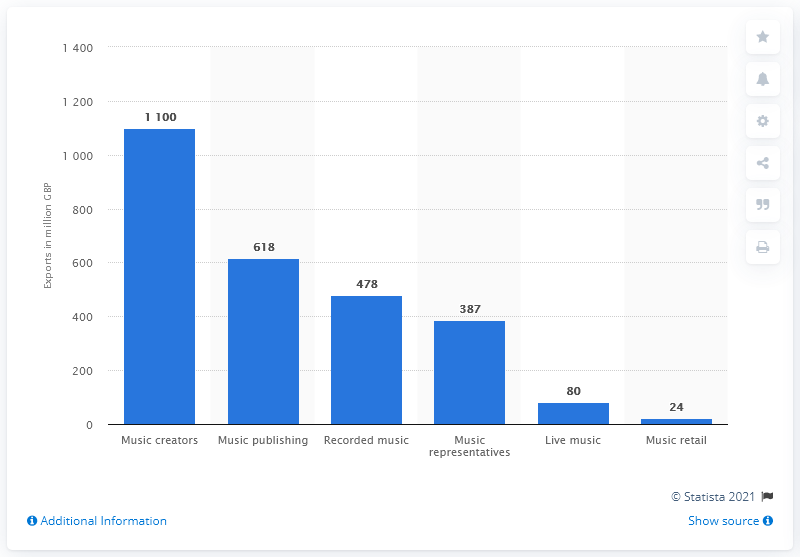

Original: {'images': [<PIL.PngImagePlugin.PngImageFile image mode=RGBA size=800x557 at 0x7F5D21BA24E0>], 'texts': [{'user': 'Can you break down the data visualization and explain its message?', 'assistant': "This statistic displays the economic contribution of the UK music industry's exports in 2018, by thematic grouping. It was estimated that British music publishing exports had a value of 618 million British pounds in 2018.", 'source': 'chart2text-statista'}]}
Turbo translation: {'images': [<PIL.PngImagePlugin.PngImageFile image mode=RGBA size=800x557 at 0x7F5D21BA0980>], 'texts': [{'user': '你能分解一下数据可视化并解释它的含义吗？', 'assistant': '该统计数据按主题分组展示了2018年英国音乐产业出口的经济贡献。据估计，2018年英国音乐出版物出口额达6.18亿英镑。', 'source': 'chart2text-statista'}]}
Plus translation: {'images': [<PIL.PngImagePlugin.PngImageFile image mode=RGBA size=800x557 at 0x7F5D21BA1940>], 'texts': [{'user': '你能剖析这份数据可视化并阐释其传达的信息吗？', 'assistant': '该统计数据按主题分组展示了2018年英国音乐产业出口的经济贡献。据估计，2018年英国音乐出版业出口价值为6.18亿英镑。', 'source': 'chart2text-statis

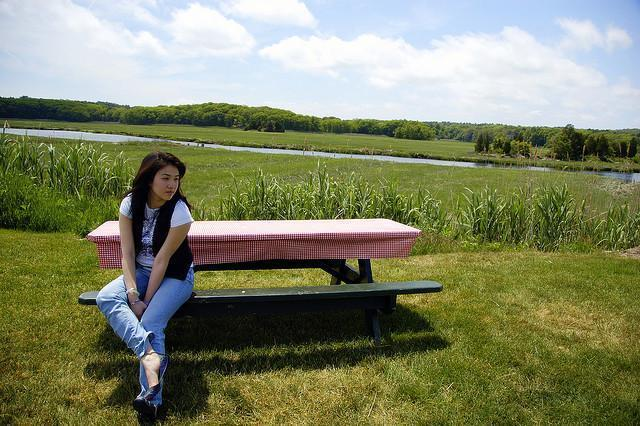

Original: {'images': [<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=640x426 at 0x7F5D21C95070>], 'texts': [{'user': "What is the name for the table the woman is sitting at?\nSelect the correct answer and articulate reasoning with the following format: 'Answer: answer\nRationale: rationale.'\nOptions: Picnic table, end table, kitchen table, conference table.", 'assistant': 'Answer: picnic table.\nRationale: This table is usually found outside so people can eat together.', 'source': 'A-OKVQA'}]}
Turbo translation: {'images': [<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=640x426 at 0x7F5D21BA1F10>], 'texts': [{'user': '这位女士正坐在哪张桌子旁？请选出正确答案，并按照以下格式阐述理由：“答案：答案\n理由：理由。”选项：野餐桌、边桌、厨房桌、会议桌。', 'assistant': '答案：野餐桌。\n理由：这种桌子通常放在室外，供人们一起用餐。', 'source': 'A-OKVQA'}]}
Plus translation: {'images': [<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=640x426 at 0x7F5D21BA09E0>], 'texts': [{'user': '这名女子正坐在哪张桌子旁？请选出正确答案，并按以下格式阐述推理过程：“答案：答案\u3000理由：理由。”\n选项：野餐桌、边桌、餐桌、会议桌。', 'assista

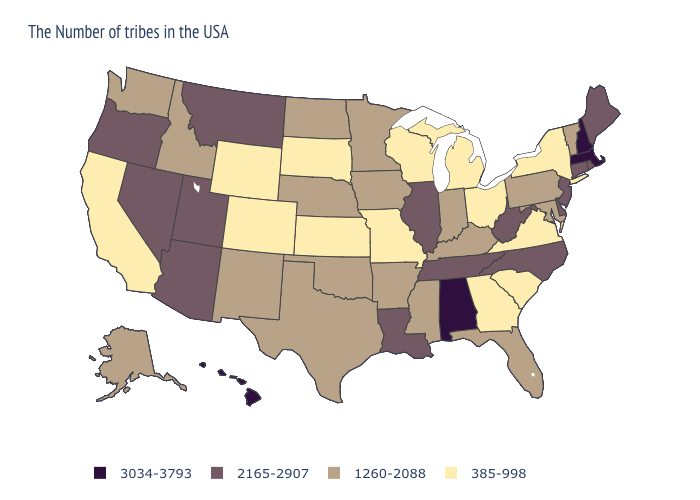

Original: {'images': [<PIL.PngImagePlugin.PngImageFile image mode=RGBA size=700x500 at 0x7F5D21B96ED0>], 'texts': [{'user': 'What is the highest value in states that border South Dakota?\nShort answer required.', 'assistant': '2165-2907.', 'source': 'MapQA'}, {'user': 'Does the first symbol in the legend represent the smallest category?\nQuick response, please.', 'assistant': 'No.', 'source': 'MapQA'}, {'user': 'What is the value of Massachusetts?\nAnswer briefly.', 'assistant': '3034-3793.', 'source': 'MapQA'}, {'user': 'Among the states that border Missouri , which have the highest value?\nShort answer required.', 'assistant': 'Tennessee, Illinois.', 'source': 'MapQA'}, {'user': 'What is the value of Nebraska?\nGive a very brief answer.', 'assistant': '1260-2088.', 'source': 'MapQA'}, {'user': 'Name the states that have a value in the range 1260-2088?\nKeep it brief.', 'assistant': 'Vermont, Maryland, Pennsylvania, Florida, Kentucky, Indiana, Mississippi, Arkansas, Minnesota, Iowa, N

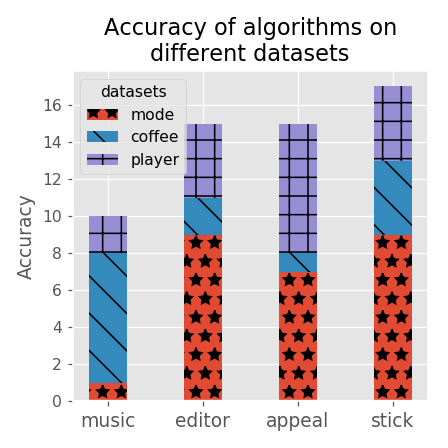

Original: {'images': [<PIL.PngImagePlugin.PngImageFile image mode=RGBA size=448x448 at 0x7F5D21B1D610>], 'texts': [{'user': 'How many algorithms have accuracy higher than 4 in at least one dataset?\nProvide a short and direct response.', 'assistant': 'Four.', 'source': 'dvqa'}, {'user': 'Which algorithm has the smallest accuracy summed across all the datasets?\nKeep it short and to the point.', 'assistant': 'Music.', 'source': 'dvqa'}, {'user': 'Which algorithm has the largest accuracy summed across all the datasets?\nYour response must be concise.', 'assistant': 'Stick.', 'source': 'dvqa'}, {'user': 'What is the sum of accuracies of the algorithm editor for all the datasets?\nGive a very brief answer.', 'assistant': '15.', 'source': 'dvqa'}, {'user': 'Is the accuracy of the algorithm stick in the dataset player smaller than the accuracy of the algorithm music in the dataset mode?\nYour response must be concise.', 'assistant': 'No.', 'source': 'dvqa'}, {'user': 'What dataset does the s

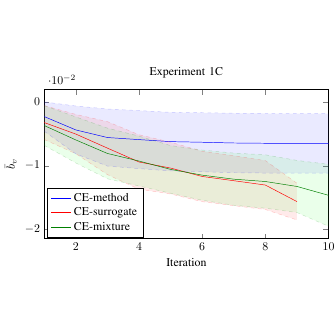

Original: {'images': [<PIL.PngImagePlugin.PngImageFile image mode=RGB size=336x336 at 0x7F5D21B94650>], 'texts': [{'user': 'Generate TikZ code for this figure.', 'assistant': "\\documentclass[conference]{IEEEtran}\n\\usepackage{tikz}\n\\usepackage{amsmath}\n\\usepackage{amsmath}\n\\usepackage{amsmath}\n\\usetikzlibrary{calc}\n\\usetikzlibrary{shapes.geometric}\n\\usetikzlibrary{external}\n\\usetikzlibrary{patterns}\n\\usetikzlibrary{shapes,arrows,fit}\n\\usetikzlibrary{positioning}\n\\usetikzlibrary{arrows.meta, calc, shapes}\n\\usetikzlibrary{graphs}\n\\usetikzlibrary{decorations.pathmorphing}\n\\usetikzlibrary{decorations.pathreplacing}\n\\usepackage{pgfplots}\n\\pgfplotsset{compat=newest}\n\\pgfplotsset{every axis legend/.append style={%\ncells={anchor=west}}\n}\n\\usetikzlibrary{arrows}\n\\tikzset{>=stealth'}\n\\usepgfplotslibrary{fillbetween}\n\\usepgfplotslibrary{groupplots}\n\n\\begin{document}\n\n\\begin{tikzpicture}[]\n\\begin{axis}[height = {6cm}, legend style = {{at={(0.01,0

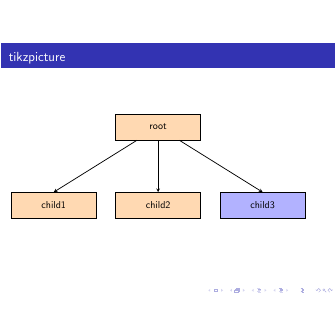

Original: {'images': [<PIL.PngImagePlugin.PngImageFile image mode=RGB size=336x336 at 0x7F5D21B1F4A0>], 'texts': [{'user': 'Replicate this image with TikZ code.', 'assistant': '\\documentclass{beamer}\n\\mode<presentation>{\\usetheme{Madrid}}\n\n\n\\usepackage[style=verbose]{biblatex}\n\\usepackage{tikz}\n\\usetikzlibrary{shapes.geometric, arrows}\n%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%\n\\tikzset{startstop/.style = {rectangle, rounded corners, minimum width=3cm, minimum height=1cm,text centered, draw=black, fill=red!30}}\n\\tikzset{io/.style = {trapezium, trapezium left angle=70, trapezium right angle=110, minimum width=3cm, minimum height=1cm, text centered, draw=black, fill=blue!30}}\n\\tikzset{process/.style = {rectangle, minimum width=3cm, minimum height=1cm, text centered, text width=3cm, draw=black, fill=orange!30}}\n\\tikzset{decision/.style = {diamond, minimum width=3cm, minimum height=1cm, text centered, draw=black

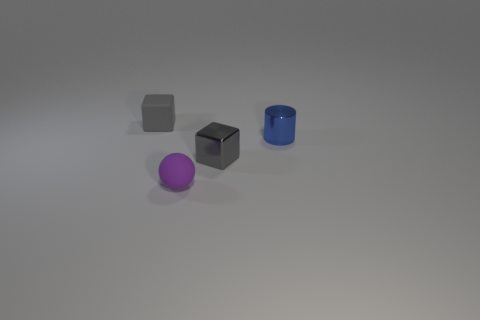

Original: {'images': [<PIL.PngImagePlugin.PngImageFile image mode=RGBA size=480x320 at 0x7F5D21B1CC80>], 'texts': [{'user': 'Are there any gray blocks that have the same material as the blue object?\nProvide a succinct answer.', 'assistant': 'Yes.', 'source': 'clevr'}, {'user': 'The tiny gray thing right of the thing to the left of the tiny purple rubber ball is made of what material?\nMake the answer very short.', 'assistant': 'Metal.', 'source': 'clevr'}, {'user': 'How big is the block that is in front of the tiny metal cylinder?\nKeep it short and to the point.', 'assistant': 'Small.', 'source': 'clevr'}, {'user': 'There is a cylinder; does it have the same color as the tiny cube right of the small rubber block?\nProvide a succinct answer.', 'assistant': 'No.', 'source': 'clevr'}, {'user': 'Are there any rubber spheres that have the same color as the small matte cube?\nOffer a terse response.', 'assistant': 'No.', 'source': 'clevr'}, {'user': 'Does the tiny ball have the same materi

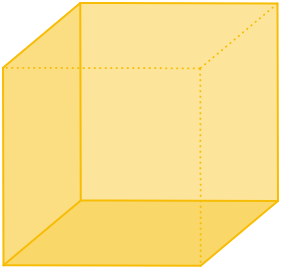

Original: {'images': [<PIL.PngImagePlugin.PngImageFile image mode=RGB size=281x269 at 0x7F5D21BA0EF0>], 'texts': [{'user': 'Question: Can you trace a square with this shape?\nChoices:\nA. no\nB. yes\nAnswer with the letter.', 'assistant': 'Answer: B', 'source': 'IconQA'}]}
Turbo translation: {'images': [<PIL.PngImagePlugin.PngImageFile image mode=RGB size=281x269 at 0x7F5D21B72E10>], 'texts': [{'user': '问题：你能用这个形状画一个正方形吗？\n选项：\nA. 不可以\nB. 可以\n请用字母作答。', 'assistant': '答案：B', 'source': 'IconQA'}]}
Plus translation: {'images': [<PIL.PngImagePlugin.PngImageFile image mode=RGB size=281x269 at 0x7F5D21B050D0>], 'texts': [{'user': '问题：你能用这个形状描绘出一个正方形吗？\n选项：\nA. 否\nB. 是\n请用字母作答。', 'assistant': '答案：B', 'source': 'IconQA'}]}




In [9]:
raw = data["train"].select(range(8))
for i in range(8):
    print(f"Sample {i}")
    raw[i]["images"][0].show()
    print("Original:", raw[i])
    print("Turbo translation:", data_turbo["train"][i])
    print("Plus translation:", data_plus["train"][i])
    print("\n")
    

## Check translated data

In [20]:
import glob
import re

file_pattern = "data/the_cauldron_CN/*.parquet"
file_list = glob.glob(file_pattern)

# Method 1: Using regex to extract the number
def extract_index(file_path):
    match = re.search(r'_(\d+)\.parquet$', file_path)
    return int(match.group(1)) if match else 0

sorted_paths = sorted(file_list, key=extract_index)

dataset = datasets.load_dataset('parquet', data_files=sorted_paths)

Generating train split: 32040 examples [00:09, 3416.84 examples/s]


In [3]:
sorted_paths

['data/the_cauldron_CN/the_cauldron_60K_CN_qwen3_mt_plus_3.parquet',
 'data/the_cauldron_CN/the_cauldron_60K_CN_qwen3_mt_plus_7.parquet',
 'data/the_cauldron_CN/the_cauldron_60K_CN_qwen3_mt_plus_11.parquet',
 'data/the_cauldron_CN/the_cauldron_60K_CN_qwen3_mt_plus_15.parquet',
 'data/the_cauldron_CN/the_cauldron_60K_CN_qwen3_mt_plus_19.parquet',
 'data/the_cauldron_CN/the_cauldron_60K_CN_qwen3_mt_plus_23.parquet',
 'data/the_cauldron_CN/the_cauldron_60K_CN_qwen3_mt_plus_27.parquet',
 'data/the_cauldron_CN/the_cauldron_60K_CN_qwen3_mt_plus_31.parquet',
 'data/the_cauldron_CN/the_cauldron_60K_CN_qwen3_mt_plus_35.parquet',
 'data/the_cauldron_CN/the_cauldron_60K_CN_qwen3_mt_plus_39.parquet',
 'data/the_cauldron_CN/the_cauldron_60K_CN_qwen3_mt_plus_43.parquet',
 'data/the_cauldron_CN/the_cauldron_60K_CN_qwen3_mt_plus_47.parquet',
 'data/the_cauldron_CN/the_cauldron_60K_CN_qwen3_mt_plus_51.parquet',
 'data/the_cauldron_CN/the_cauldron_60K_CN_qwen3_mt_plus_55.parquet',
 'data/the_cauldron_CN

In [3]:
for i in sorted_paths:
    file = datasets.load_dataset('parquet', data_files=i)["train"]
    if file.shape[0] != 4 and file.shape[0] != 8:
        print(i)

data/the_cauldron_CN/the_cauldron_60K_CN_qwen3_mt_plus_3159.parquet


Generating train split: 8 examples [00:00, 860.08 examples/s]
Generating train split: 8 examples [00:00, 1150.19 examples/s]
Generating train split: 8 examples [00:00, 1168.82 examples/s]
Generating train split: 8 examples [00:00, 1177.10 examples/s]
Generating train split: 8 examples [00:00, 960.32 examples/s]
Generating train split: 8 examples [00:00, 1184.66 examples/s]
Generating train split: 8 examples [00:00, 1451.57 examples/s]
Generating train split: 8 examples [00:00, 1243.40 examples/s]
Generating train split: 8 examples [00:00, 822.41 examples/s]
Generating train split: 8 examples [00:00, 1048.58 examples/s]
Generating train split: 8 examples [00:00, 1388.96 examples/s]
Generating train split: 8 examples [00:00, 898.45 examples/s]
Generating train split: 8 examples [00:00, 1064.41 examples/s]
Generating train split: 8 examples [00:00, 1440.85 examples/s]
Generating train split: 8 examples [00:00, 1518.16 examples/s]
Generating train split: 8 examples [00:00, 1037.49 examples

KeyboardInterrupt: 

In [14]:
file = datasets.load_dataset('parquet', data_files="data/the_cauldron_CN/the_cauldron_60K_CN_qwen3_mt_plus_3159.parquet")["train"]
file.shape

Generating train split: 8 examples [00:00, 1121.17 examples/s]


(8, 2)

In [12]:
file[7]

{'images': [<PIL.PngImagePlugin.PngImageFile image mode=RGBA size=448x448>],
 'texts': [{'assistant': '零。',
   'source': 'dvqa',
   'user': '在至少一个数据集中，有多少种算法的准确率高于8？\n请给出非常简短的回答。'},
  {'assistant': 'Move。',
   'source': 'dvqa',
   'user': '在任何数据集中，哪个算法的准确率最高？\n请给出简洁的答案。'},
  {'assistant': 'Get。',
   'source': 'dvqa',
   'user': '在任何数据集中，哪个算法的准确率最低？\n请给出简短而直接的回答。'},
  {'assistant': '8。',
   'source': 'dvqa',
   'user': '整个图表中报告的最高准确率是多少？\n请给出简洁的答案。'},
  {'assistant': '2。',
   'source': 'dvqa',
   'user': '整个图表中报告的最低准确率是多少？\n你的回答必须简洁。'},
  {'assistant': 'Get。',
   'source': 'dvqa',
   'user': '在所有数据集中，哪个算法的准确率之和最小？\n请确保你的答案简短。'},
  {'assistant': 'Move。',
   'source': 'dvqa',
   'user': '在所有数据集中，哪个算法的准确率之和最大？\n请给出简洁的答案。'},
  {'assistant': '13。',
   'source': 'dvqa',
   'user': '算法get在所有数据集上的准确率之和是多少？\n请给出简短的回答。'},
  {'assistant': '是的。',
   'source': 'dvqa',
   'user': '算法get在数据集woman中的准确率是否小于算法move在数据集party中的准确率？\n请给出非常简短的回答。'},
  {'assistant': '否。',
   'source': 'dvqa',
   'user': '图表中的数

In [21]:
dataset["train"][3159]

{'images': [<PIL.PngImagePlugin.PngImageFile image mode=RGBA size=699x158>],
 'texts': [{'user': '金科房地产公司及其子公司合并财务报表附注，持续的不确定税务立场：公司在某些美国境外司法管辖区，主要是加拿大和墨西哥，受所得税管辖。\n根据司法管辖区和税务问题的不同，税务评估的诉讼时效从三年到七年不等。\n在每个司法管辖区提交的纳税申报表均受当地税务机关审查。\n该公司目前正接受加拿大税务局、墨西哥税务机关和美国国税局（IRS）的审计。\n2011年10月，IRS发布了一份拟议调整通知，根据税法第482条，提议拒绝KRS就出售澳大利亚上市公司Valad Property Ltd.普通股所主张的资本损失。\n由于该调整是根据税法第482条进行的，IRS认为它可以依据税法第857(b)(7)条征收100%的“惩罚性”税，并拒绝资本损失扣除。\n拟议调整通知表明，IRS打算对公司征收4090万美元的100%“惩罚性”税，并拒绝KRS所主张的资本损失。\n公司及其外部律师已考虑了IRS的评估，并认为有足够的文件证明转让具有有效的商业目的，包括最近的案例历史支持类似立场。\n因此，公司强烈反对IRS关于将税法第482条应用于股份处置、征收100%惩罚性税以及同时主张惩罚性税并拒绝资本损失扣除的立场。\n公司收到了一份拟议评估通知，并提交了书面抗议，要求召开IRS上诉办公室会议。\n2014年11月，一场上诉听证会由管理层及其律师、IRS合规小组和一名IRS上诉官员出席，在此期间，IRS合规部门提出了支持其立场的论点，如本文所述。\n管理层及其律师提出了反驳论点，支持其立场。\n此事目前正由上诉官员审理。\n公司打算在此事中积极捍卫其立场，并相信自己会胜诉。\n预计这些审计的结果不会对公司2019年的财务报表产生重大影响。\n2013年，公司提前采用了ASU 2013-11，并前瞻性地重新分类了其不确定税务立场准备金的一部分。\n不确定税务立场准备金包括与公司2019年加拿大业务相关的金额。\n公司有未确认的税务利益，报告为递延税资产，可用于解决与公司2019年加拿大不确定税务立场相关的调整。\n公司减少了与其加拿大业务相关的1230万美元的不确定税务立场准备金，并根据ASU 2013

In [7]:
data = load_mm_data(select_data="all", seed=42)

In [17]:
data["train"][3159]

{'images': [<PIL.PngImagePlugin.PngImageFile image mode=RGBA size=699x158>],
 'texts': [{'user': 'Kimco realty corporation and subsidiaries notes to consolidated financial statements , continued uncertain tax positions : the company is subject to income tax in certain jurisdictions outside the u.s. , principally canada and mexico .\nThe statute of limitations on assessment of tax varies from three to seven years depending on the jurisdiction and tax issue .\nTax returns filed in each jurisdiction are subject to examination by local tax authorities .\nThe company is currently under audit by the canadian revenue agency , mexican tax authority and the u.s .\nInternal revenue service ( 201cirs 201d ) .\nIn october 2011 , the irs issued a notice of proposed adjustment , which proposes pursuant to section 482 of the code , to disallow a capital loss claimed by krs on the disposition of common shares of valad property ltd. , an australian publicly listed company .\nBecause the adjustment is b

In [20]:
try:
    model = "qwen-mt-plus"
    texts = []
    example = copy.deepcopy(data["train"][9179])
    for i, turn in enumerate(example["texts"]):
        user_msg = re.sub(r'(?:\r\n|\r|\n){2,}', '\n', turn["user"])
        user_msg = user_msg.strip()
        assist_msg = re.sub(r'(?:\r\n|\r|\n){2,}', '\n', turn["assistant"])
        assist_msg = assist_msg.strip()
        texts.append("USER:\n" + user_msg + "\nASSISTANT:\n" + assist_msg)
        texts.append("\n\n")
    
    print(texts)
    texts = "".join(texts)
    print("Raw before translation: ", texts)
    text_zh = english_to_chinese(texts, model=model)
    print("Raw after translation: ", text_zh)
    text_zh = list(filter(None, re.split(r"(?:\r\n|\n|\r){2,}", text_zh)))
    print("Translation after split: ",text_zh)
    text_zh = [list(filter(None,re.split(r"用户：\n|\n助手：\n", text))) for text in text_zh]
except Exception as e:
    print(str(e))
    print(type(e))
    print(e.body)
    example["source"] = "Translation failed"

['USER:\n$ 15 million for fire control programs due to increased deliveries ( primarily apache ) , partially offset by lower risk retirements ( primarily sniper ae ) .\nAdjustments not related to volume , including net profit booking rate adjustments and other matters , were approximately $ 95 million lower for 2014 compared to 2013 .\nBacklog backlog increased in 2015 compared to 2014 primarily due to higher orders on pac-3 , lantirn/sniper and certain tactical missile programs , partially offset by lower orders on thaad .\nBacklog decreased in 2014 compared to 2013 primarily due to lower orders on thaad and fire control systems programs , partially offset by higher orders on certain tactical missile programs and pac-3 .\nTrends we expect mfc 2019s net sales to be flat or experience a slight decline in 2016 as compared to 2015 .\nOperating profit is expected to decrease by approximately 20 percent , driven by contract mix and fewer risk retirements in 2016 compared to 2015 .\nAccordin

In [19]:
text_zh

[['由于交付量增加（主要是阿帕奇），火控项目增加了1500万美元，部分被较低的风险退役（主要是狙击手AE）所抵消。\n与数量无关的调整，包括净利润预订率调整和其他事项，2014年比2013年低约9500万美元。\n2015年积压订单比2014年增加，主要是由于PAC-3、LANTIRN/狙击手以及某些战术导弹项目的订单增加，部分被THAAD订单减少所抵消。\n2014年积压订单比2013年减少，主要是由于THAAD和火控系统项目的订单减少，部分被某些战术导弹项目和PAC-3的订单增加所抵消。\n我们预计，与2015年相比，MFC 2019年的净销售额在2016年将持平或略有下降。\n营业利润预计将下降约20%，原因是合同组合以及2016年比2015年风险退役减少。\n因此，营业利润率预计将从2015年的水平下降。\n如前所述，2015年11月6日，我们收购了西科斯基，并将西科斯基业务纳入我们的MST业务部门。\n自2015年11月6日收购之日起至2015年12月31日，收购的西科斯基业务的结果已纳入我们的财务结果。\n因此，截至2015年12月31日的年度合并经营业绩和MST业务部门的经营业绩并未反映西科斯基一整年的运营。\n我们的MST业务部门为各种军用和民用直升机、舰船和潜艇任务及作战系统；旋翼和固定翼飞机的任务系统和传感器；海上和陆基导弹防御系统；雷达系统；濒海战斗舰（LCS）；模拟和训练服务；以及无人系统和技术提供设计、制造、服务和支持。\n此外，MST还支持客户在网络安全方面的需求，并通过复杂的任务解决方案为国防应用提供通信和指挥控制能力。\nMST 2019年的主要项目包括黑鹰和海鹰直升机、宙斯盾作战系统（宙斯盾）、LCS、太空围栏、先进鹰眼雷达系统和TPQ-53雷达系统。\nMST 2019年的经营成果包括以下内容（以百万计）：。\n与2014年相比，MST 2019年在2015年的净销售额增加了3.59亿美元，即4%（4%），比2014年高。\n这一增长归因于来自西科斯基的约4亿美元净销售额，扣除为核算2015年第四季度收购该业务所需的调整；以及约2.2亿美元用于综合作战系统和传感器项目，主要是由于最近授予的项目（太空围栏）的启动。\n这些增长部分被海底系统项目约1.5亿美元的较低净销售额所抵消，原因是由于战区部队削减导致的体积减少（主要是持续威胁

In [7]:
example 

{'images': [<PIL.PngImagePlugin.PngImageFile image mode=RGBA size=800x557>],
 'texts': [{'user': 'What is the main idea being communicated through this graph?',
   'assistant': 'In financial year 2020, the highest proportion of production land was used to cultivate fruits in the Indian state of Arunachal Pradesh, which amounted to around 48 thousand hectares. In comparison, the size of croplands utilized for plantations, aromatic and medicinal crops accounted for less than 0.5 percent of the total area of cultivation in this state. The total area of production in Arunachal Pradesh was about 69 thousand hectares in the financial year 2020.',
   'source': 'chart2text-statista'}],
 'source': 'Translation failed'}

### Get rid of skipped sample

In [29]:
import re
with open("skipped_sample_index.txt", "r") as f:
    cont = f.read()

In [30]:
re.split(r",\n", cont)

['7406 Output data may contain inappropriate content',
 '9179 list index out of range',
 '9736 list index out of range',
 '14998 list index out of range',
 "15759 Error code: 429 - {'error': {'message': 'You have exceeded your current request limit. For details, see: https://help.aliyun.com/zh/model-studio/error-code#rate-limit', 'type': 'limit_requests', 'param': None, 'code': 'limit_requests'}, 'request_id': '2059c680-b53c-977c-aff0-637639f52dbf'}",
 "15760 Error code: 429 - {'error': {'message': 'You have exceeded your current request limit. For details, see: https://help.aliyun.com/zh/model-studio/error-code#rate-limit', 'type': 'limit_requests', 'param': None, 'code': 'limit_requests'}, 'request_id': 'c5390b47-09f2-9618-9b02-fba8c24c414c'}",
 "15761 Error code: 429 - {'error': {'message': 'You have exceeded your current request limit. For details, see: https://help.aliyun.com/zh/model-studio/error-code#rate-limit', 'type': 'limit_requests', 'param': None, 'code': 'limit_requests'}

In [32]:
skipped_index = [re.split(r" ", text)[0] for text in re.split(r",\n", cont)]

In [35]:
for i in skipped_index:
    print(i + "\n")
    print(dataset["train"][int(i)])

7406

{'images': [<PIL.PngImagePlugin.PngImageFile image mode=RGBA size=800x557 at 0x7FF768268A70>], 'texts': [{'user': 'What is the main idea being communicated through this graph?', 'assistant': 'In financial year 2020, the highest proportion of production land was used to cultivate fruits in the Indian state of Arunachal Pradesh, which amounted to around 48 thousand hectares. In comparison, the size of croplands utilized for plantations, aromatic and medicinal crops accounted for less than 0.5 percent of the total area of cultivation in this state. The total area of production in Arunachal Pradesh was about 69 thousand hectares in the financial year 2020.', 'source': 'chart2text-statista'}]}
9179

{'images': [<PIL.PngImagePlugin.PngImageFile image mode=RGBA size=699x107 at 0x7FF768268C20>], 'texts': [{'user': '由于交付量增加（主要是阿帕奇），火控项目增加了1500万美元，部分被较低的风险退役（主要是狙击手AE）所抵消。\n与数量无关的调整，包括净利润预订率调整和其他事项，2014年比2013年低约9500万美元。\n2015年积压订单比2014年增加，主要是由于PAC-3、LANTIRN/狙击手以及某些战术导弹项目的订单增加，部分被THAAD订单减少所抵

In [39]:
skipped_index = [int(idx) for idx in skipped_index]

In [40]:
len(skipped_index)

27

In [41]:
filtered_dataset = dataset.filter(lambda example, idx: idx not in skipped_index, with_indices=True)

Filter: 100%|██████████| 32040/32040 [02:51<00:00, 186.30 examples/s]


In [42]:
filtered_dataset.shape

{'train': (32013, 2)}

In [44]:
filtered_dataset["train"].to_parquet(f"data/the_cauldron_CN/the_cauldron_CN_32K_qwen3_mt_plus.parquet")

Creating parquet from Arrow format: 100%|██████████| 321/321 [00:02<00:00, 145.20ba/s]


2175618427

In [45]:
dataset2 = datasets.load_dataset('parquet', data_files=f"data/the_cauldron_CN/the_cauldron_CN_32K_qwen3_mt_plus.parquet")["train"]

Generating train split: 32013 examples [00:03, 8225.89 examples/s] 


In [46]:
dataset2[0]

{'images': [<PIL.PngImagePlugin.PngImageFile image mode=RGBA size=448x448>],
 'texts': [{'user': '在至少一个类别中，有多少个物体被超过4人偏好？\n请简明作答。',
   'assistant': '三。',
   'source': 'dvqa'},
  {'user': '在任何一个类别中，哪个物体最不受欢迎？\n请给出极简回复。',
   'assistant': '专利。',
   'source': 'dvqa'},
  {'user': '在整个图表中，有多少人喜欢最不受欢迎的物体？\n请提供简洁答案。',
   'assistant': '2。',
   'source': 'dvqa'},
  {'user': '在所有类别中，哪个物体被最少的人偏好？\n您的回答必须简明。',
   'assistant': '婴儿。',
   'source': 'dvqa'},
  {'user': '在所有类别中，哪个物体被最多的人偏好？\n请给出简短而直接的回答。',
   'assistant': '司机。',
   'source': 'dvqa'},
  {'user': '在所有类别中，共有多少人偏好“婴儿”这个物体？\n请给出极简答案。',
   'assistant': '16。',
   'source': 'dvqa'},
  {'user': '在“学位”类别中，“司机”这个物体是否比“专利”这个物体在“地块”类别中被更少的人偏好？\n请给出简短回复。',
   'assistant': '是。',
   'source': 'dvqa'},
  {'user': '浅蓝颜色代表哪个类别？\n请给出极简回复。', 'assistant': '地块。', 'source': 'dvqa'},
  {'user': '在“地块”类别中，有多少人偏好“专利”这个物体？\n请提供简洁答案。',
   'assistant': '9。',
   'source': 'dvqa'},
  {'user': '从左起第三个柱状堆栈的标签是什么？\n请给出简短而直接的回答。',
   'assistant': '婴儿。',
   'source': 'dvqa